In [ ]:
# Titanic Dataset - Exploratory Data Analysis

## About This Project
This project analyzes the real Titanic passenger dataset 
from 1912 containing 891 passengers and 12 columns.
The goal is to find patterns in who survived and who didn't
using Python data analysis and visualization tools.

## Dataset Details
- 891 rows, 12 columns
- Columns: PassengerId, Survived, Pclass, Name, Sex, 
  Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked

## Steps Performed
1. Loaded dataset from URL
2. Explored shape, head, tail, datatypes
3. Found and fixed missing values
   - Age → filled with median
   - Cabin → filled with 'unknown'
   - Embarked → filled with 'unknown'
4. Checked for duplicates
5. Analyzed survival by gender, class and age
6. Visualized findings using seaborn and matplotlib

## Key Findings
- Overall only 342 out of 891 passengers survived (38%)
- Females survived 74% vs males only 19%
- Class 1 (rich) survived 63% vs Class 3 (poor) only 24%
- Children (0-10) survived more than adults
- Higher fare passengers had better survival chances
- "Women and children first" rule confirmed by data

## Conclusion
Survival on the Titanic was strongly influenced by 
gender, class and wealth. Women and children were 
prioritized. Rich passengers had better access to 
lifeboats due to their cabin location on upper decks.
However some wealthy passengers still died showing 
that survival was never fully guaranteed.

## Tools Used
- Python
- Pandas — data cleaning and analysis
- Matplotlib — basic visualization
- Seaborn — advanced visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print('='*50)
print("rows & columns:", df.shape)
print('='*50)
print(df.head())
print('='*50)
print(df.tail())
print('='*50)
print('COUNTS:\n',df.count())
print('='*50)
print('---MISSING VLUES---')
print(df.isnull().sum())
print('duplicates:',df.duplicated().sum())





rows & columns: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   

In [3]:
df['Cabin']=df['Cabin'].fillna('unknown')
df['Age']=df['Age'].fillna(df.median)
df['Embarked']=df['Embarked'].fillna('unknown')
print('---MISSING VLUES---')
print(df.isnull().sum())



---MISSING VLUES---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [4]:
print('SURVIVED')
print('\nSurvived=',df['Survived'].value_counts())
print('='*50)
print('SURVIVED BY GENDER')
print(df.groupby('Sex')['Survived'].mean())
print('='*50)
print('SURVIVED BY PCLASS')
print(df.groupby('Pclass')['Survived'].mean())

SURVIVED

Survived= Survived
0    549
1    342
Name: count, dtype: int64
SURVIVED BY GENDER
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
SURVIVED BY PCLASS
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


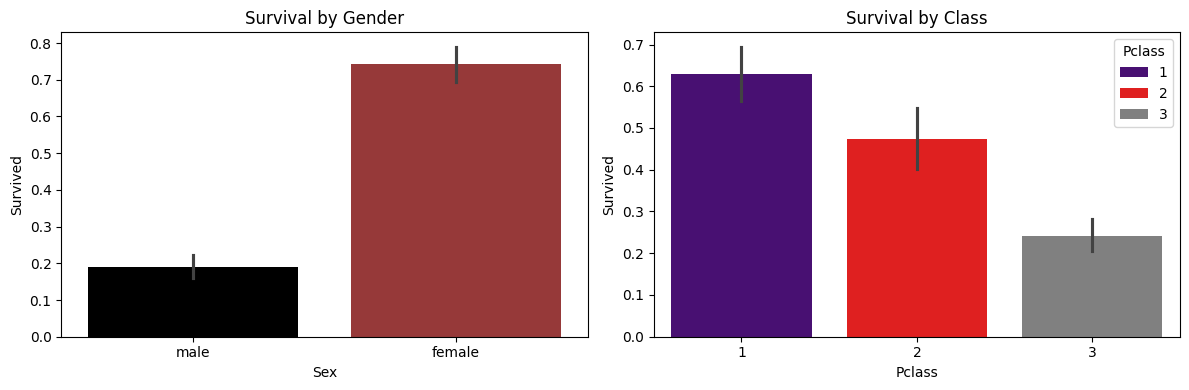

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], hue='Sex', palette=['black','brown'])
axes[0].set_title('Survival by Gender')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], hue='Pclass', palette=['Indigo','red','grey'])
axes[1].set_title('Survival by Class')

plt.tight_layout()
plt.show()

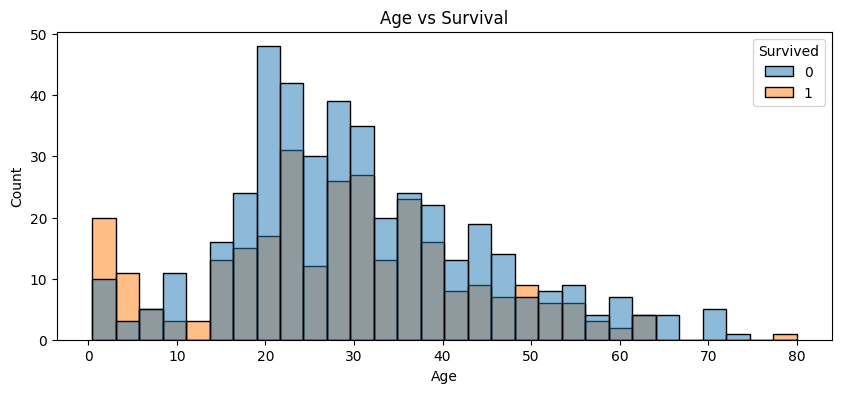

In [6]:
df['Age']=pd.to_numeric(df['Age'], errors='coerce')
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.title('Age vs Survival')
plt.show()

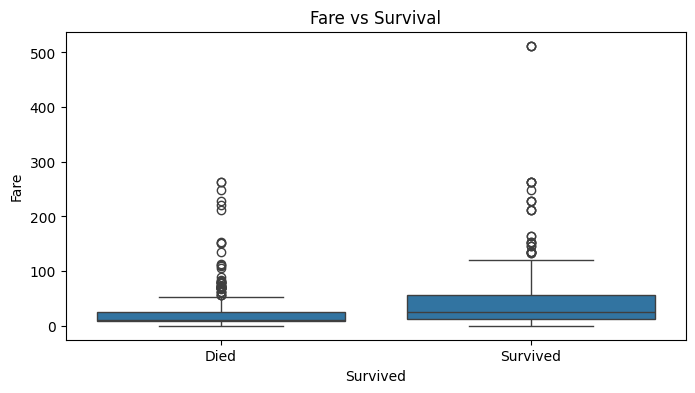

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare vs Survival')
plt.xticks([0,1],['Died','Survived'])
plt.show()

In [ ]:
## My Personal Insight
Every number in this dataset represents a real human life.
The inequality in survival rates shows how social class 
and gender affected who lived and who died.
As a Data Scientist, we must always remember the human 
story behind the data.